In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("wine.csv")

df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
df.shape

(178, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [6]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [7]:
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

## Histograms

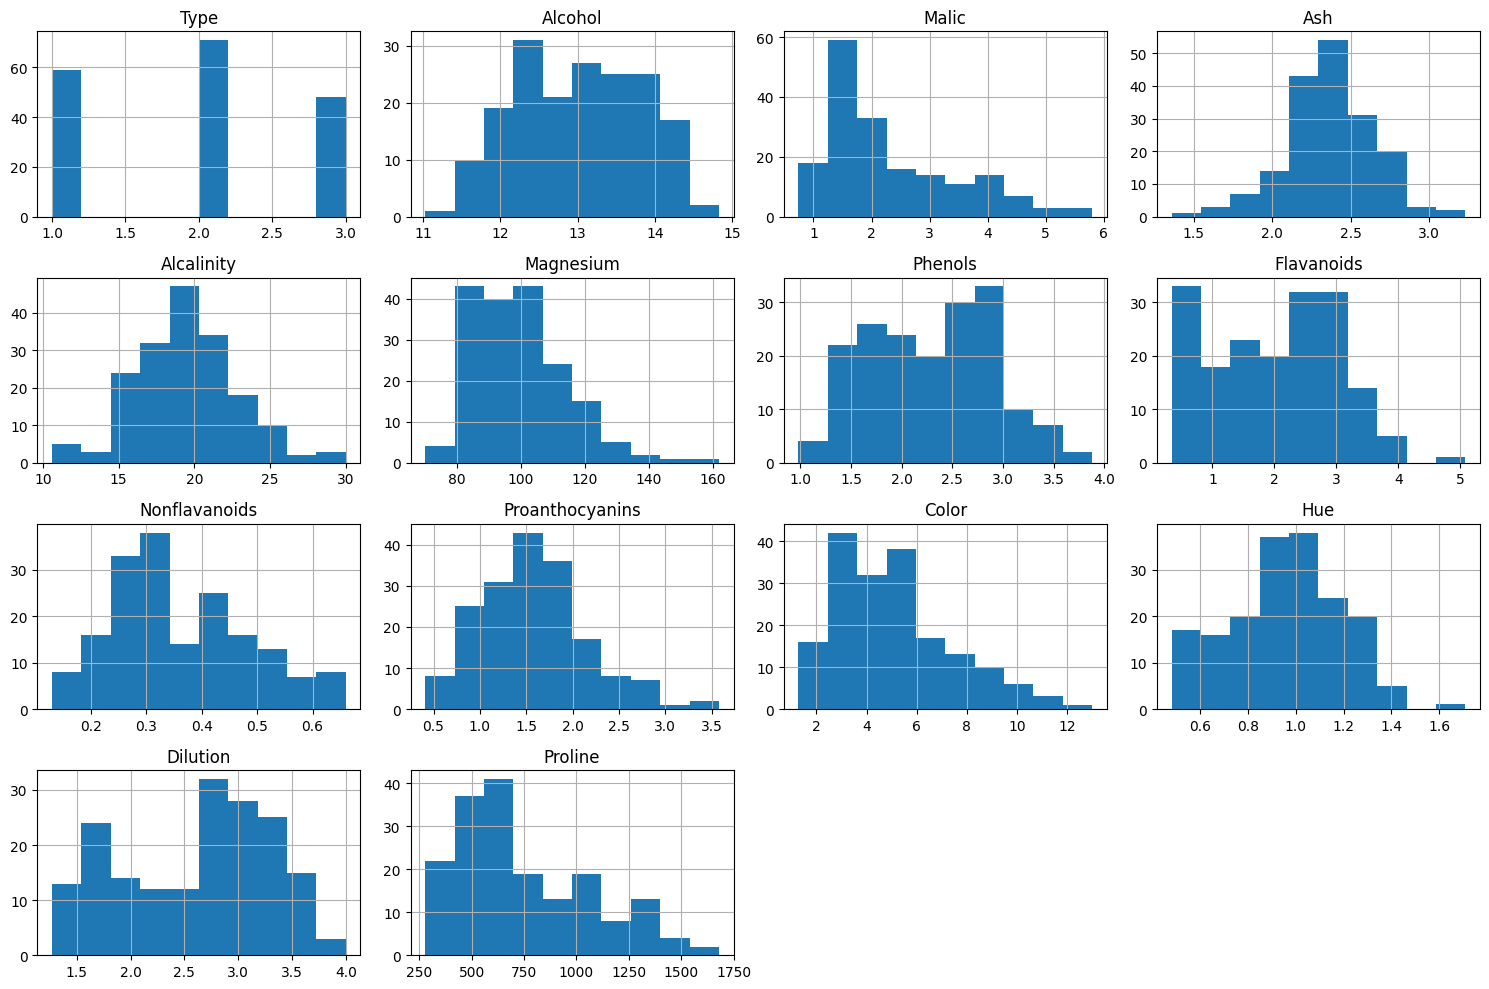

In [8]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

## Boxplots (Outlier Check)

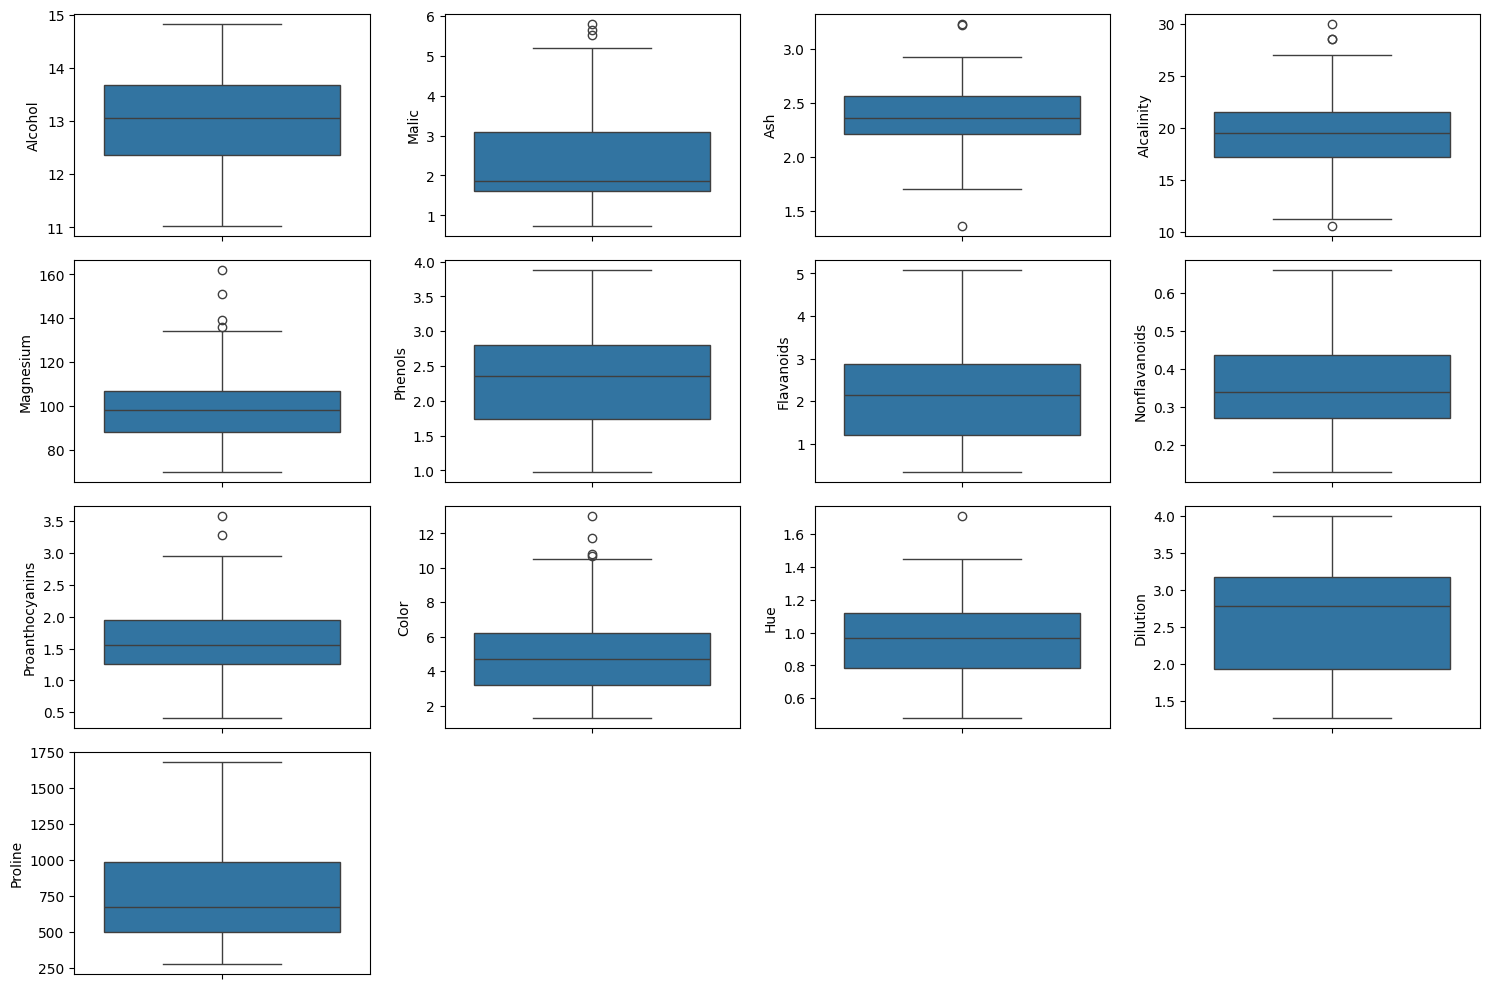

In [9]:
plt.figure(figsize=(15,10))

for i, col in enumerate(df.columns[1:]):  # skipping target column (Type)
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

## Outlier Handling (IQR Method)

In [10]:
num_cols = df.columns[1:]  

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)

IQR = Q3 - Q1

df = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) | 
          (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

## Check Dataset After Outlier Removal

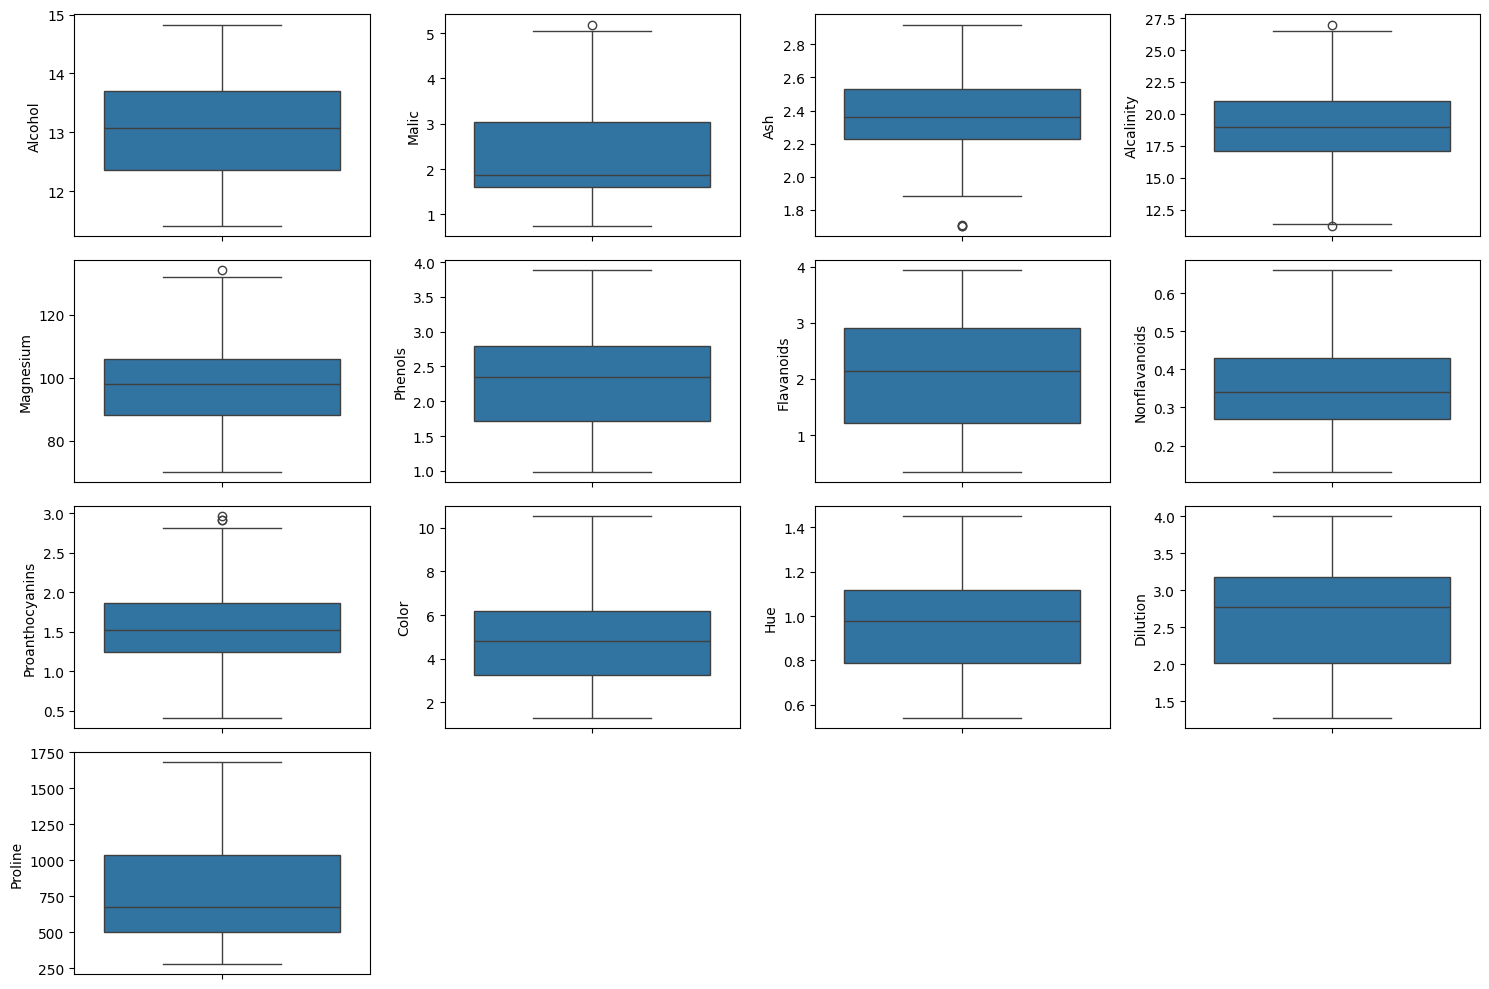

In [11]:
df.shape

plt.figure(figsize=(15,10))

for i, col in enumerate(df.columns[1:]):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

###### After applying IQR method, extreme outliers are reduced, but some mild outliers may still appear due to natural variation in the data. This is acceptable in real-world datasets.

## Density Plots

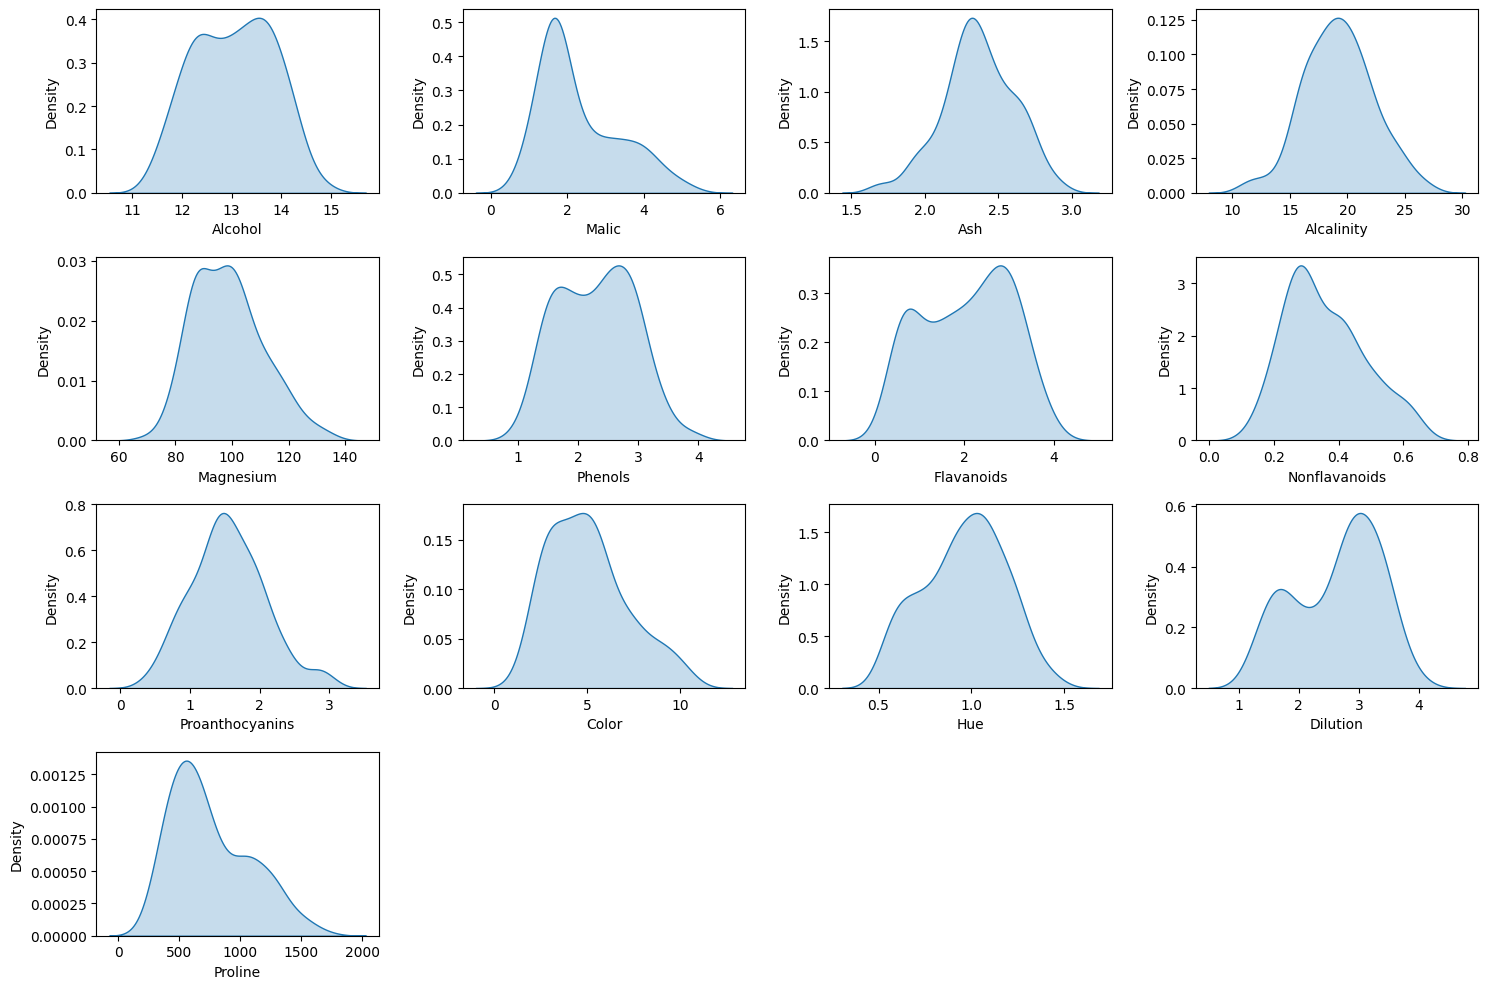

In [12]:
plt.figure(figsize=(15,10))

for i, col in enumerate(df.columns[1:]):
    plt.subplot(4,4,i+1)
    sns.kdeplot(df[col], fill=True)

plt.tight_layout()
plt.show()

## Correlation Matrix

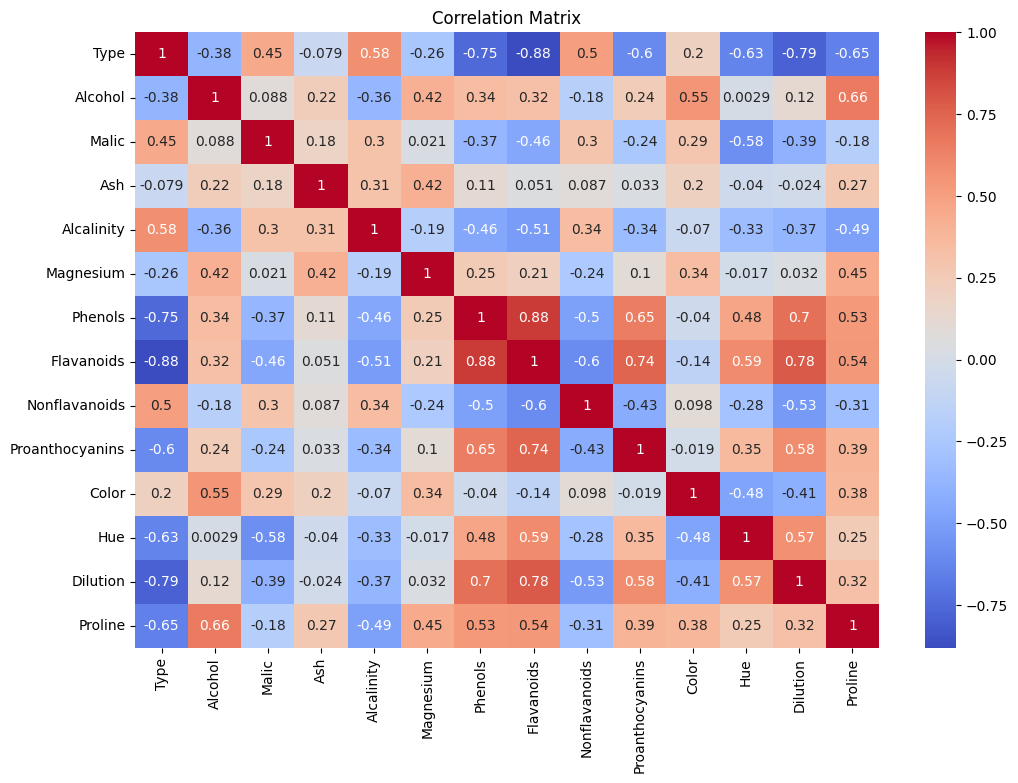

In [13]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

## Standardization

In [14]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Type', axis=1)
y = df['Type']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Apply PCA

In [15]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

## Explained Variance Ratio

In [16]:
explained_variance = pca.explained_variance_ratio_

explained_variance

array([0.38853448, 0.20487624, 0.09547051, 0.06919384, 0.05789018,
       0.04289108, 0.03510666, 0.0259047 , 0.02394086, 0.01980589,
       0.0175546 , 0.01308515, 0.00574581])

## Scree Plot (Optimal Components)

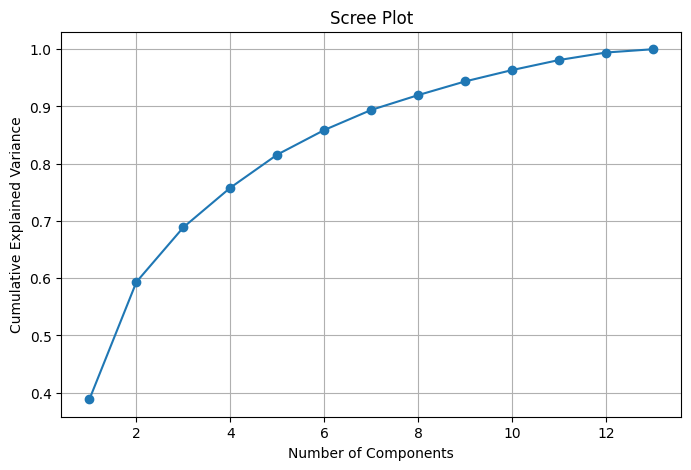

In [17]:
plt.figure(figsize=(8,5))

plt.plot(range(1, len(explained_variance)+1),
         explained_variance.cumsum(),
         marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.grid(True)

plt.show()

## Select Optimal Principal Components

In [19]:
np.cumsum(explained_variance)

array([0.38853448, 0.59341072, 0.68888122, 0.75807507, 0.81596525,
       0.85885633, 0.89396299, 0.91986769, 0.94380856, 0.96361444,
       0.98116904, 0.99425419, 1.        ])

## Apply PCA with Optimal Components

In [20]:
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)
X_pca.shape

(161, 10)

## KMeans Clustering on Original Data

In [21]:
from sklearn.cluster import KMeans
kmeans_original = KMeans(n_clusters=3, random_state=42)
clusters_original = kmeans_original.fit_predict(X_scaled)

## Visualize Clusters

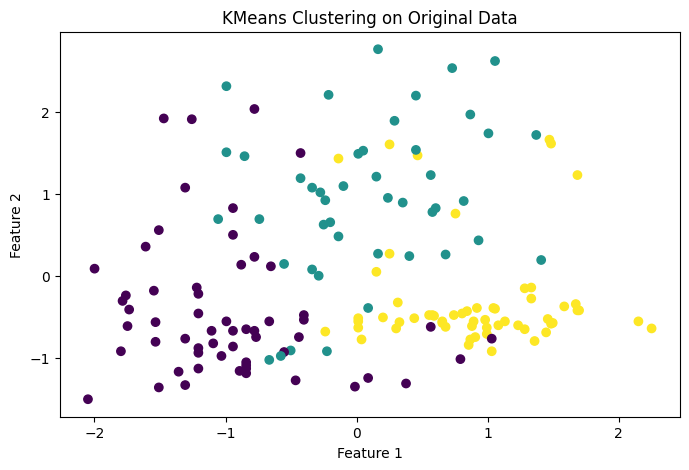

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(X_scaled[:,0], X_scaled[:,1],
            c=clusters_original)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KMeans Clustering on Original Data")

plt.show()

## Evaluate Clustering

In [23]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

silhouette_original = silhouette_score(X_scaled, clusters_original)

davies_original = davies_bouldin_score(X_scaled, clusters_original)

print("Silhouette Score:", silhouette_original)
print("Davies-Bouldin Index:", davies_original)

Silhouette Score: 0.3010147337033009
Davies-Bouldin Index: 1.3011073993472457


## KMeans Clustering on PCA Data

In [24]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)

clusters_pca = kmeans_pca.fit_predict(X_pca)

## Visualize Clusters (PCA Data)

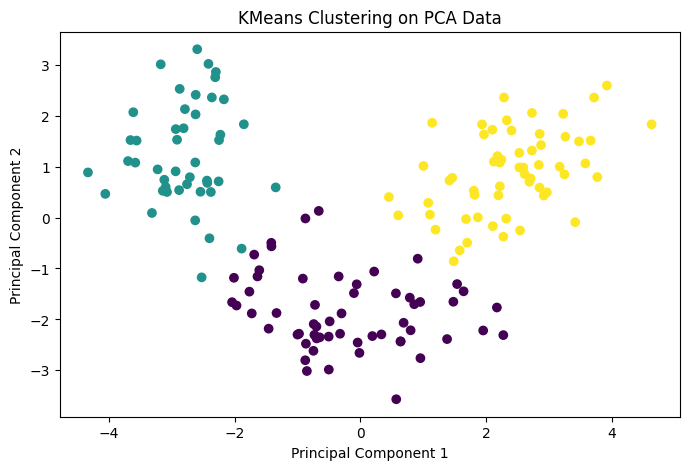

In [25]:
plt.figure(figsize=(8,5))

plt.scatter(X_pca[:,0], X_pca[:,1],
            c=clusters_pca)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KMeans Clustering on PCA Data")

plt.show()

## Evaluate Clustering (PCA Data)

In [26]:
silhouette_pca = silhouette_score(X_pca, clusters_pca)

davies_pca = davies_bouldin_score(X_pca, clusters_pca)

print("Silhouette Score:", silhouette_pca)
print("Davies-Bouldin Index:", davies_pca)

Silhouette Score: 0.31531228087974517
Davies-Bouldin Index: 1.2525408038497254


## Compare Clustering Results

In [27]:
comparison = pd.DataFrame({
    "Metric": ["Silhouette Score", "Davies-Bouldin Index"],
    "Original Data": [silhouette_original, davies_original],
    "PCA Data": [silhouette_pca, davies_pca]
})

comparison

,Metric,Original Data,PCA Data
0,Silhouette Score,0.301015,0.315312
1,Davies-Bouldin Index,1.301107,1.252541


# Analysis & Interpretation


###### 1. PCA reduced dimensionality while retaining most of the variance.
###### 2. Clustering on PCA-transformed data may improve visualization and reduce noise.
###### 3. Higher Silhouette Score indicates better cluster separation.
###### 4. Lower Davies-Bouldin Index indicates better clustering quality.
###### 5. PCA helps improve computational efficiency and interpretation.

# Final Conclusion


######  1. PCA successfully reduced the dimensionality of the dataset.
######  2. Most of the variance was retained using selected principal components.
######  3. KMeans clustering was applied on both original and PCA-transformed data.
######  4. PCA-based clustering provided simpler visualization and efficient computation.
######  5. Dimensionality reduction can improve clustering performance by reducing noise and redundancy.
######  6. PCA is useful when datasets contain many correlated features.